# Triagem visual de bagagens com YOLO26
Detecta pessoas, mochilas, bolsas e malas em imagem ou vídeo, associa cada bagagem à pessoa mais próxima e gera uma triagem pelo tamanho aparente. **Não mede peso ou dimensões reais.**

## 1. Ambiente e configurações
Ative uma GPU T4 no Colab, se disponível.

In [1]:
import sys, subprocess
subprocess.run([sys.executable,'-m','pip','install','-q','ultralytics'],check=True)
import os, cv2, math, shutil, zipfile, torch
import numpy as np, pandas as pd
from collections import Counter,defaultdict
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image as DisplayImage,Video,display
if shutil.which('ffmpeg') is None: raise RuntimeError('FFmpeg não encontrado.')
DEVICE=0 if torch.cuda.is_available() else 'cpu'
MODEL_NAME='yolo26n.pt'; CONF=0.30; LIM_MEDIO=0.35; LIM_ALERTA=0.60; DIST_MAX=1.20
CLASSES=[0,24,26,28]; NOMES={0:'pessoa',24:'mochila',26:'bolsa',28:'mala'}
IMG_EXT={'.jpg','.jpeg','.png','.bmp','.webp','.avif','.heic'}
VID_EXT={'.mp4','.mov','.avi','.mkv','.webm','.mpeg','.mpg','.m4v'}
COLUNAS=['bagagem_id','pessoa_id','tipo','confianca','proporcao','tempo_s','resultado']
OUT='resultados_triagem'; os.makedirs(OUT,exist_ok=True)
print('Ambiente pronto. Dispositivo:',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ambiente pronto. Dispositivo: Tesla T4


## 2. Envie exatamente uma imagem ou um vídeo
A mídia será convertida para um formato padronizado antes da análise.

In [2]:
up=files.upload()
if len(up)!=1: raise ValueError('Envie exatamente um arquivo.')
ORIGINAL=next(iter(up.keys()))
if not os.path.isfile(ORIGINAL): raise FileNotFoundError(ORIGINAL)
ext=os.path.splitext(ORIGINAL)[1].lower()
if ext in IMG_EXT: TIPO='imagem'
elif ext in VID_EXT: TIPO='video'
else: raise ValueError(f'Extensão não aceita: {ext}')
if TIPO=='imagem':
    ENTRADA=os.path.join(OUT,'entrada.png')
    cmd=['ffmpeg','-y','-loglevel','error','-i',ORIGINAL,'-frames:v','1',ENTRADA]
else:
    ENTRADA=os.path.join(OUT,'entrada.mp4')
    cmd=['ffmpeg','-y','-loglevel','error','-i',ORIGINAL,'-an','-c:v','libx264','-preset','veryfast','-crf','23','-pix_fmt','yuv420p','-movflags','+faststart',ENTRADA]
p=subprocess.run(cmd,capture_output=True,text=True)
if p.returncode!=0 or not os.path.isfile(ENTRADA): raise RuntimeError('Falha ao converter mídia | detalhes: '+p.stderr[-1000:])
print('Arquivo validado:',ORIGINAL,'| tipo:',TIPO,'| padronizado:',ENTRADA)

Saving BagagemTeste2.webp to BagagemTeste2.webp
Arquivo validado: BagagemTeste2.webp | tipo: imagem | padronizado: resultados_triagem/entrada.png


## 3. Modelo e funções de análise
A associação compara a base da bagagem com a base das pessoas e normaliza a distância pela altura da pessoa.

In [3]:
try: model=YOLO(MODEL_NAME)
except Exception as e: raise RuntimeError(f'Falha ao carregar {MODEL_NAME}: {e}')
if not set(CLASSES).issubset(set(model.names)): raise RuntimeError('Modelo sem as classes COCO necessárias.')
try:
    _=model.predict(np.zeros((320,320,3),dtype=np.uint8),classes=CLASSES,conf=CONF,device=DEVICE,verbose=False)[0]
except Exception as e:
    raise RuntimeError(f'O modelo carregou, mas falhou no teste de inferência: {e}')
def altura(c): return max(1.0,float(c[3]-c[1]))
def base(c): return ((c[0]+c[2])/2.0,c[3])
def classificar(r):
    if r>=LIM_ALERTA:return 'Encaminhar para triagem',(0,0,255)
    if r>=LIM_MEDIO:return 'Bagagem média',(0,200,255)
    return 'Bagagem pequena',(0,180,0)
def extrair(res,tracking=False):
    if res.boxes is None or len(res.boxes)==0:return []
    cs=res.boxes.xyxy.detach().cpu().numpy(); cls=res.boxes.cls.detach().cpu().numpy().astype(int)
    conf=res.boxes.conf.detach().cpu().numpy()
    ids=res.boxes.id.detach().cpu().numpy().astype(int) if tracking and res.boxes.id is not None else np.arange(len(cs))
    return [{'caixa':c,'classe':int(k),'conf':float(f),'id':int(i)} for c,k,f,i in zip(cs,cls,conf,ids)]
def associar(bag,pessoas):
    if not pessoas:return None
    bx,by=base(bag['caixa']); pares=[]
    for p in pessoas:
        px,py=base(p['caixa']); pares.append((math.hypot(bx-px,by-py)/altura(p['caixa']),p))
    d,p=min(pares,key=lambda z:z[0]); return (p,d) if d<=DIST_MAX else None
def texto(img,s,x,y,cor):
    font,scale,esp=cv2.FONT_HERSHEY_SIMPLEX,.50,2; (w,h),b=cv2.getTextSize(s,font,scale,esp)
    x=max(0,min(int(x),img.shape[1]-w-8)); y=max(h+b+6,int(y))
    cv2.rectangle(img,(x,y-h-b-6),(x+w+8,y+2),cor,-1); cv2.putText(img,s,(x+4,y-b),font,scale,(255,255,255),esp,cv2.LINE_AA)
def analisar(img,dets,tempo=0.0,hist=None):
    ps=[d for d in dets if d['classe']==0]; bs=[d for d in dets if d['classe'] in (24,26,28)]; obs=[]
    for p in ps:
        x1,y1,x2,y2=map(int,p['caixa']); cv2.rectangle(img,(x1,y1),(x2,y2),(255,100,0),2); texto(img,f"Pessoa {p['id']}",x1,y1,(255,100,0))
    for b in bs:
        x1,y1,x2,y2=map(int,b['caixa']); par=associar(b,ps)
        if par is None:
            cor=(140,140,140); cv2.rectangle(img,(x1,y1),(x2,y2),cor,2); texto(img,NOMES[b['classe']]+' sem associação',x1,y1,cor); continue
        p,d=par; r=altura(b['caixa'])/altura(p['caixa']); status,cor=classificar(r)
        cv2.rectangle(img,(x1,y1),(x2,y2),cor,3); texto(img,f"{NOMES[b['classe']]} R={r:.2f}",x1,y1,cor)
        cv2.line(img,tuple(map(int,base(p['caixa']))),tuple(map(int,base(b['caixa']))),cor,2)
        o={'bagagem_id':b['id'],'pessoa_id':p['id'],'tipo':NOMES[b['classe']],'confianca':round(b['conf'],4),'proporcao':round(r,4),'tempo_s':round(tempo,2),'resultado':status}
        obs.append(o)
        if hist is not None:hist[b['id']].append(o)
    return img,obs
print('Modelo pronto:',MODEL_NAME)

Modelo pronto: yolo26n.pt


## 4. Processamento
Imagem usa predição independente. Vídeo usa ByteTrack com estado persistente apenas entre quadros consecutivos.

In [4]:
CSV=os.path.join(OUT,'relatorio.csv')
if TIPO=='imagem':
    img=cv2.imread(ENTRADA)
    if img is None or img.size==0:raise RuntimeError('OpenCV não leu a imagem padronizada.')
    res=model.predict(img,classes=CLASSES,conf=CONF,device=DEVICE,verbose=False)[0]
    img,obs=analisar(img,extrair(res)); VISUAL=os.path.join(OUT,'imagem_analisada.jpg')
    if not cv2.imwrite(VISUAL,img):raise RuntimeError('Falha ao salvar imagem.')
    df=pd.DataFrame(obs,columns=COLUNAS)
else:
    cap=cv2.VideoCapture(ENTRADA)
    if not cap.isOpened():raise RuntimeError('OpenCV não abriu o vídeo padronizado.')
    fps=float(cap.get(cv2.CAP_PROP_FPS)); fps=fps if np.isfinite(fps) and fps>0 else 30.0
    w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)); total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if w<=0 or h<=0:cap.release();raise RuntimeError('Dimensões inválidas no vídeo.')
    bruto=os.path.join(OUT,'resultado_bruto.avi'); wr=cv2.VideoWriter(bruto,cv2.VideoWriter_fourcc(*'MJPG'),fps,(w,h))
    if not wr.isOpened():cap.release();raise RuntimeError('Falha ao iniciar gravador.')
    hist=defaultdict(list); n=0
    try:
        while True:
            ok,img=cap.read()
            if not ok:break
            n+=1; res=model.track(img,persist=True,tracker='bytetrack.yaml',classes=CLASSES,conf=CONF,device=DEVICE,verbose=False)[0]
            img,_=analisar(img,extrair(res,True),n/fps,hist); wr.write(img)
            if n%100==0:print(f'Processados {n}/{total or "?"} quadros')
    finally:cap.release();wr.release()
    if n==0:raise RuntimeError('Nenhum quadro válido no vídeo.')
    VISUAL=os.path.join(OUT,'video_analisado.mp4')
    q=subprocess.run(['ffmpeg','-y','-loglevel','error','-i',bruto,'-c:v','libx264','-preset','veryfast','-crf','23','-pix_fmt','yuv420p','-movflags','+faststart',VISUAL],capture_output=True,text=True)
    if q.returncode!=0 or not os.path.isfile(VISUAL):raise RuntimeError('Falha no MP4 final | detalhes: '+q.stderr[-800:])
    resumo=[]
    for bid,lista in hist.items():
        r=float(np.median([o['proporcao'] for o in lista])); status,_=classificar(r)
        resumo.append({'bagagem_id':bid,'pessoa_id':Counter(o['pessoa_id'] for o in lista).most_common(1)[0][0],'tipo':Counter(o['tipo'] for o in lista).most_common(1)[0][0],'confianca':round(float(np.mean([o['confianca'] for o in lista])),4),'proporcao':round(r,4),'tempo_s':lista[0]['tempo_s'],'resultado':status})
    df=pd.DataFrame(resumo,columns=COLUNAS)
df.to_csv(CSV,index=False,encoding='utf-8-sig')
print('Concluído. Bagagens associadas:',len(df)); display(df)
if df.empty:print('Nenhuma associação encontrada; CSV criado com cabeçalhos.')

Concluído. Bagagens associadas: 3


,bagagem_id,pessoa_id,tipo,confianca,proporcao,tempo_s,resultado
0,2,0,mala,0.4932,0.5163,0.0,Bagagem média
1,3,0,mochila,0.4385,0.3611,0.0,Bagagem média
2,4,1,mala,0.3531,0.3696,0.0,Bagagem média


## 5. Visualização e download
A imagem ou o vídeo e o CSV são reunidos em um único ZIP.

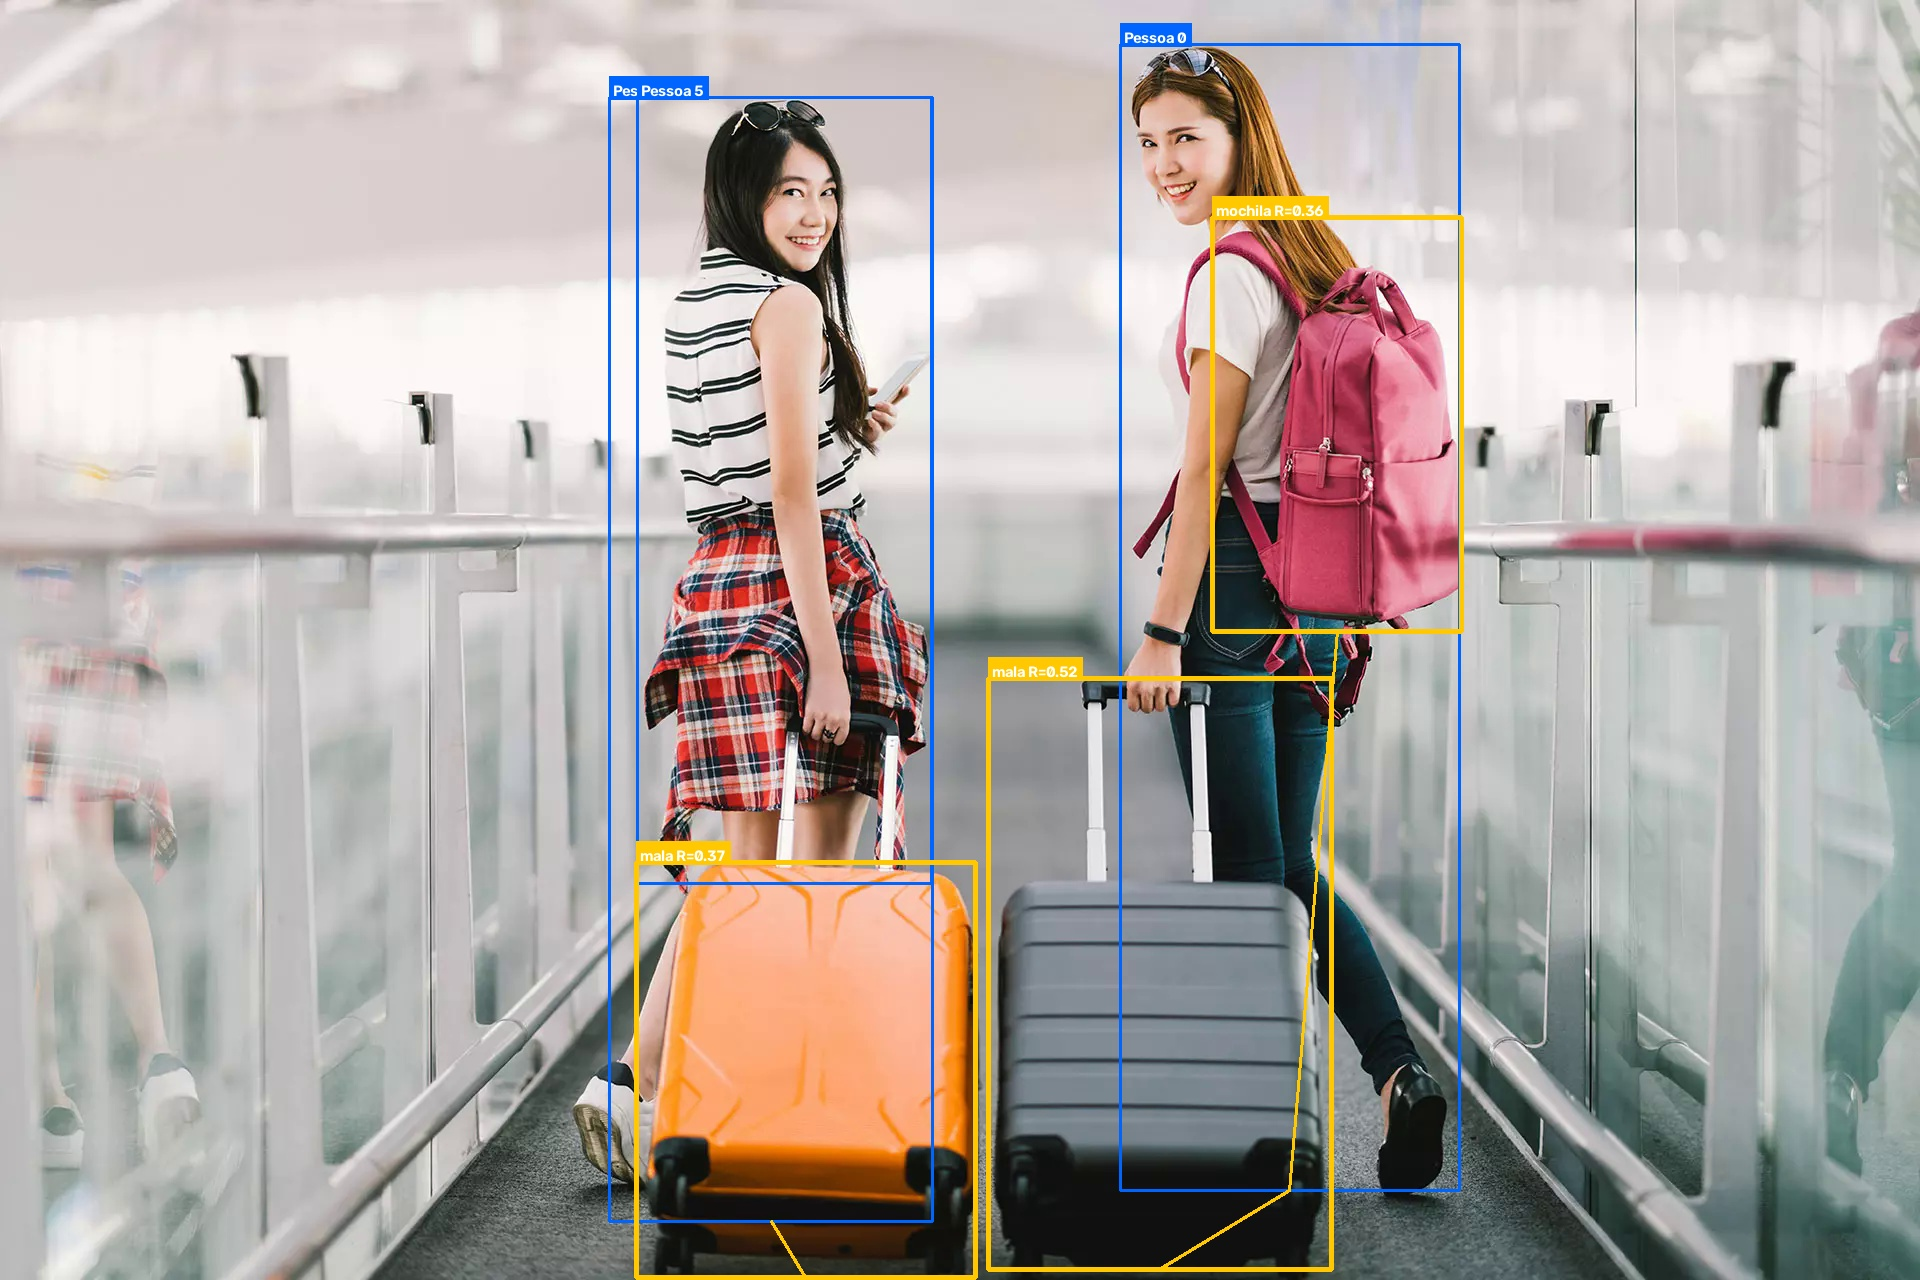

Pacote pronto: resultados_triagem_yolo26.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
display(DisplayImage(filename=VISUAL,width=900) if TIPO=='imagem' else Video(VISUAL,embed=True,width=900))
PACOTE='resultados_triagem_yolo26.zip'
with zipfile.ZipFile(PACOTE,'w',zipfile.ZIP_DEFLATED) as z:
    z.write(VISUAL,arcname=os.path.basename(VISUAL)); z.write(CSV,arcname=os.path.basename(CSV))
print('Pacote pronto:',PACOTE); files.download(PACOTE)

## Limitações
- A proporção em pixels varia com distância, perspectiva e oclusão.
- O sistema não mede peso ou dimensões reais.
- Em cenas lotadas, a associação por proximidade pode errar.
- Uma aplicação real exigiria câmera calibrada e área controlada.